# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [12]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

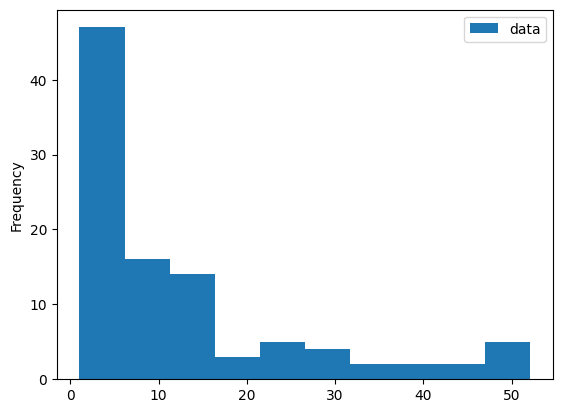

In [13]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

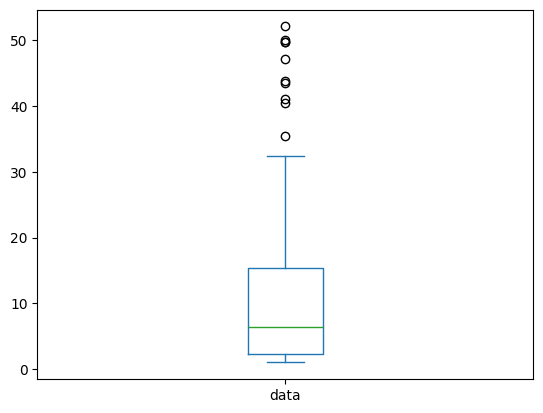

In [14]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284

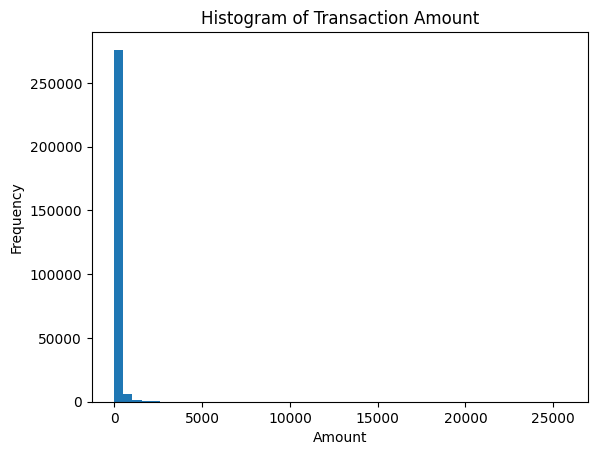

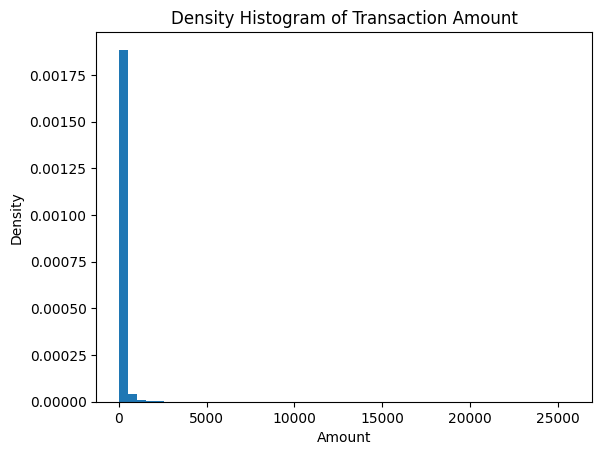

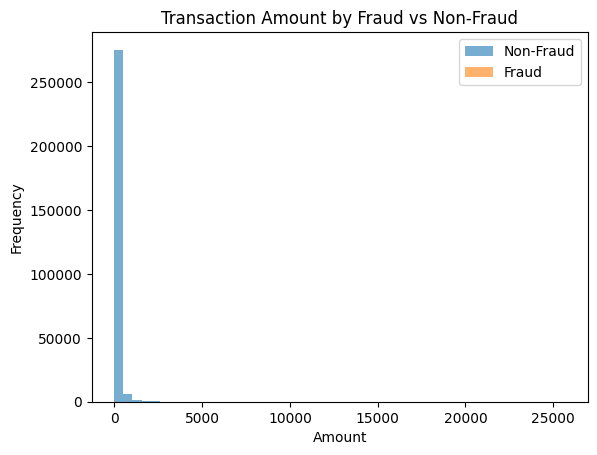

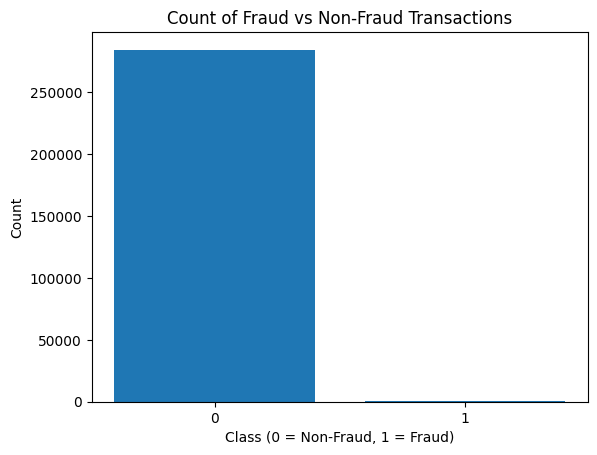

/var/folders/2y/zwy095dx4pv0v_d2ywk3w40r0000gn/T/ipykernel_3482/2862179655.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_fraud, fraud], labels=["Non-Fraud", "Fraud"])


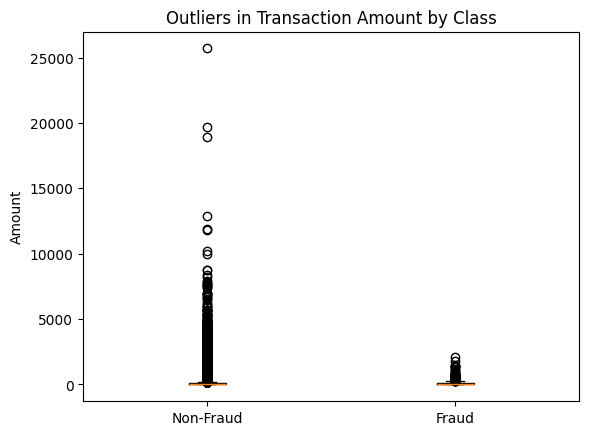

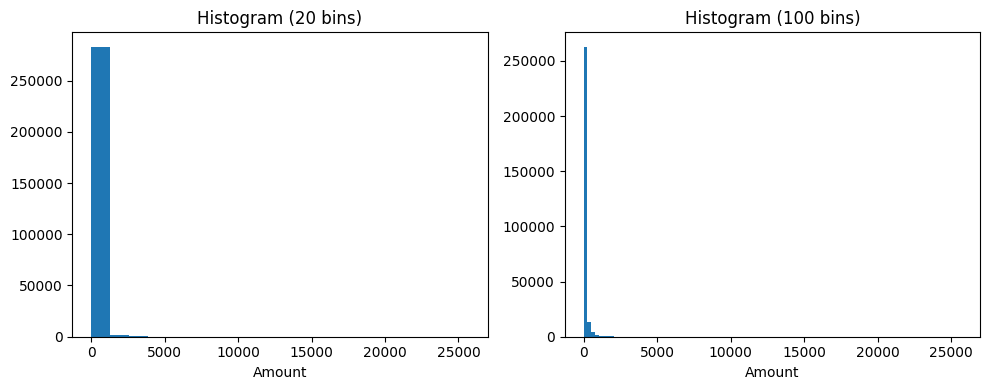

In [15]:
#Load dataset (local CSV)
df = pd.read_csv("creditcard.csv")

# Basic info and statistics
print("DATA INFO")
print(df.info())

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

# Mean, Median, Min, Max, Mode
print("\nSUMMARY STATS (Amount & Time)")
print(df[["Amount", "Time"]].agg(["mean", "median", "min", "max"]))

print("\nMODE")
print("Amount mode:", df["Amount"].mode())
print("Time mode:", df["Time"].mode())

# Histogram (Amount)
plt.figure()
plt.hist(df["Amount"], bins=50)
plt.title("Histogram of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Histogram variant: Density (KDE-like)
plt.figure()
plt.hist(df["Amount"], bins=50, density=True)
plt.title("Density Histogram of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

# Grouped histogram (Fraud vs Non-Fraud)
fraud = df[df["Class"] == 1]["Amount"]
non_fraud = df[df["Class"] == 0]["Amount"]

plt.figure()
plt.hist(non_fraud, bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(fraud, bins=50, alpha=0.6, label="Fraud")
plt.title("Transaction Amount by Fraud vs Non-Fraud")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Bar plot (Categorical Variable: Class)
class_counts = df["Class"].value_counts()

plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Count of Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# Box plot (Outliers)
plt.figure()
plt.boxplot([non_fraud, fraud], labels=["Non-Fraud", "Fraud"])
plt.title("Outliers in Transaction Amount by Class")
plt.ylabel("Amount")
plt.show()

# Effect of bin size
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["Amount"], bins=20)
plt.title("Histogram (20 bins)")
plt.xlabel("Amount")

plt.subplot(1,2,2)
plt.hist(df["Amount"], bins=100)
plt.title("Histogram (100 bins)")
plt.xlabel("Amount")

plt.tight_layout()
plt.show()

Conclusion: The transaction amount data are highly right-skewed, with most transactions occurring at low values.
The dataset is extremely imbalanced, with far fewer fraud cases than non-fraud cases, which is expected in real-world fraud data.
Outliers are clearly present, especially in transaction amounts, and are more pronounced in fraud transactions.
Grouped histograms show that fraud and non-fraud transactions have different distribution patterns.
Changing bin sizes reveals different levels of detail; smaller bins expose finer structure while larger bins smooth the distribution.
Overall, the data are realistic, interpretable, and suitable for fraud detection analysis.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

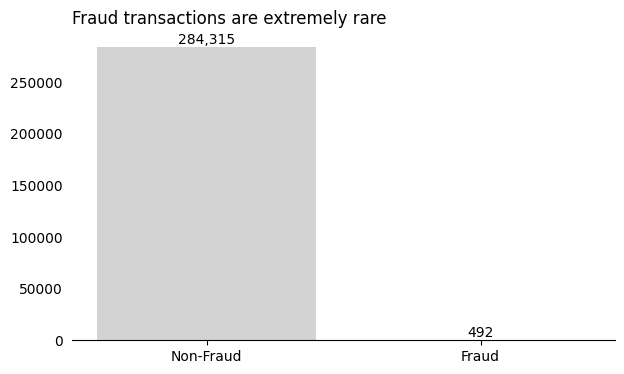

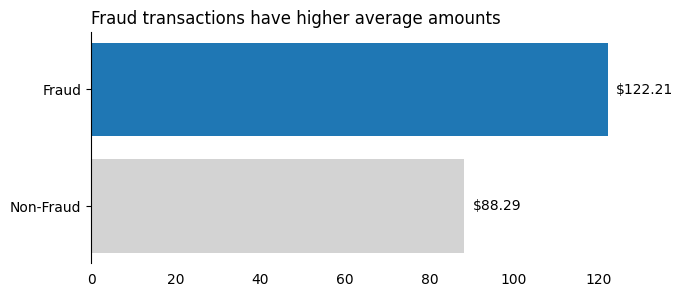

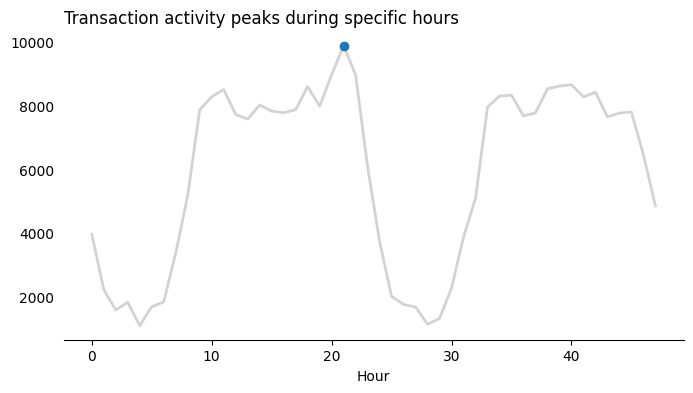

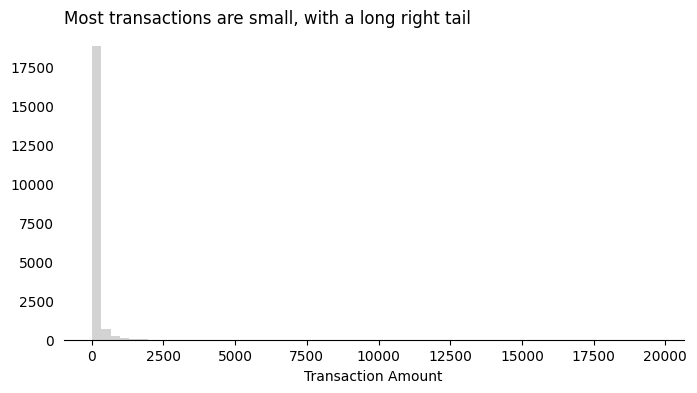

In [16]:
df = pd.read_csv("creditcard.csv")

class_counts = df["Class"].value_counts().sort_index()
avg_amount = df.groupby("Class")["Amount"].mean()

df["Hour"] = (df["Time"] // 3600).astype(int)
tx_per_hour = df.groupby("Hour").size()

amount_sample = df["Amount"].sample(20000, random_state=1)

plt.figure(figsize=(7, 4))
colors = ["lightgray", "#1f77b4"]
bars = plt.bar(["Non-Fraud", "Fraud"], class_counts.values, color=colors)

plt.title("Fraud transactions are extremely rare", loc="left")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.tick_params(left=False)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("")
plt.ylabel("")
plt.show()

plt.figure(figsize=(7, 3))
plt.barh(["Non-Fraud", "Fraud"], avg_amount.values, color=["lightgray", "#1f77b4"])

plt.title("Fraud transactions have higher average amounts", loc="left")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tick_params(bottom=False)

for i, v in enumerate(avg_amount.values):
    plt.text(v + 2, i, f"${v:.2f}", va="center")

plt.xlabel("")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tx_per_hour.index, tx_per_hour.values, color="lightgray", linewidth=2)
plt.plot(
    tx_per_hour.index[tx_per_hour.values.argmax()],
    tx_per_hour.max(),
    "o",
    color="#1f77b4"
)

plt.title("Transaction activity peaks during specific hours", loc="left")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.tick_params(left=False)

plt.xlabel("Hour")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(amount_sample, bins=60, color="lightgray")

plt.title("Most transactions are small, with a long right tail", loc="left")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.tick_params(left=False)

plt.xlabel("Transaction Amount")
plt.ylabel("")
plt.show()

## Univariate Analysis Conclusions – PaySim Dataset

1. Distribution Shape:  
Most numeric features, including transaction amounts and balances, are strongly right-skewed with heavy tails. The median is consistently lower than the mean, confirming non-normal distributions.  

2. Outliers:  
There are multiple high-value transactions that appear as statistical outliers, but they are meaningful and reflect unusual or potentially fraudulent activity rather than errors.

3. Grouped Histograms:  
Fraudulent transactions show different distributions from non-fraudulent ones, particularly in transaction amounts and originating balances, indicating a strong predictive signal.

4. Categorical Variables:  
Features like transaction type are imbalanced, with some categories being rare. This may require preprocessing for modeling but accurately represents the dataset’s real-world distribution.

5. Histogram Bin Effects:  
Using smaller bin widths reveals detailed structure among low-value transactions, while larger bins highlight overall trends.

6. Minimum and Maximum Values:  
Numeric columns span from zero to very large amounts, consistent with typical financial transaction data.

Overall Assessment:  
The dataset is usable for fraud detection and anomaly analysis. The presence of skewness, meaningful outliers, and group-based differences provides valuable insights for modeling and AML-related tasks.